### K=3 with 100

Device: cuda

Experiment : stage1_K3
K=3, T=1, Optimizer=Adam, LR=0.01

Train: 2,360 | Test: 11

Model parameters: 48,932

Training started — max 50 epochs, early stopping patience=10
  Gradient check: 18 params, 2 near-zero
Epoch   1/50 | Train loss: 0.01817 | Val PSNR: 25.21 dB | SSIM: 0.8048 | Time: 408.8s
  -> Best model saved (PSNR: 25.21 dB)
  Gradient check: 18 params, 2 near-zero
Epoch   2/50 | Train loss: 0.00435 | Val PSNR: 26.96 dB | SSIM: 0.8187 | Time: 405.2s
  -> Best model saved (PSNR: 26.96 dB)
  Gradient check: 18 params, 2 near-zero
Epoch   3/50 | Train loss: 0.00352 | Val PSNR: 26.23 dB | SSIM: 0.8273 | Time: 405.1s
Epoch   4/50 | Train loss: 0.00342 | Val PSNR: 26.82 dB | SSIM: 0.8223 | Time: 429.5s
Epoch   5/50 | Train loss: 0.00334 | Val PSNR: 26.94 dB | SSIM: 0.8261 | Time: 447.6s
Epoch   6/50 | Train loss: 0.00322 | Val PSNR: 26.71 dB | SSIM: 0.8277 | Time: 405.3s
Epoch   7/50 | Train loss: 0.00311 | Val PSNR: 27.52 dB | SSIM: 0.8282 | Time: 406.4s
  -> Best mod

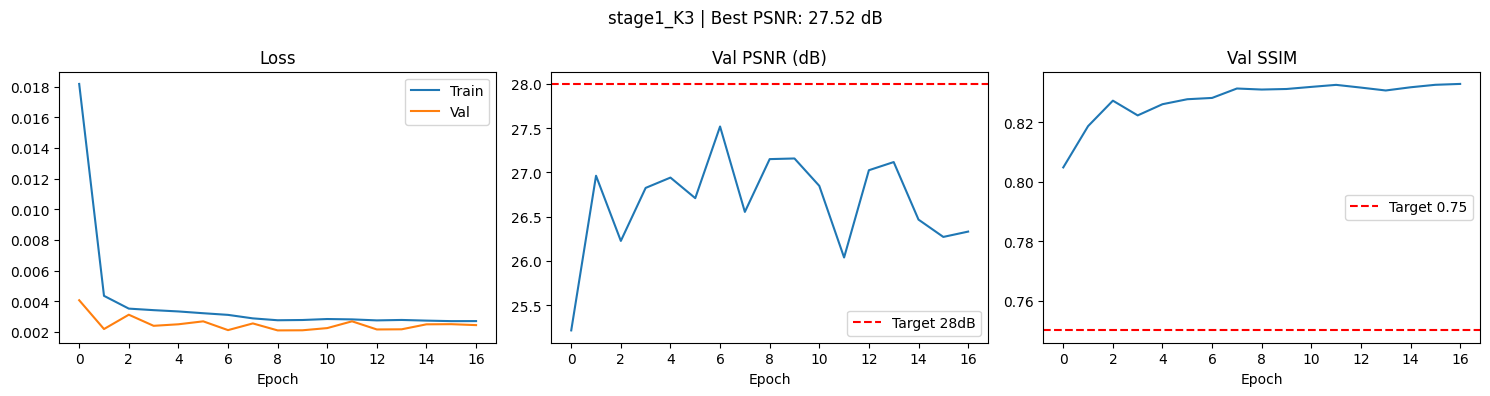

/tmp/ipykernel_2162924/4226431950.py:449: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(os.path.join(SAVE_DIR, 'best_model.pth')))


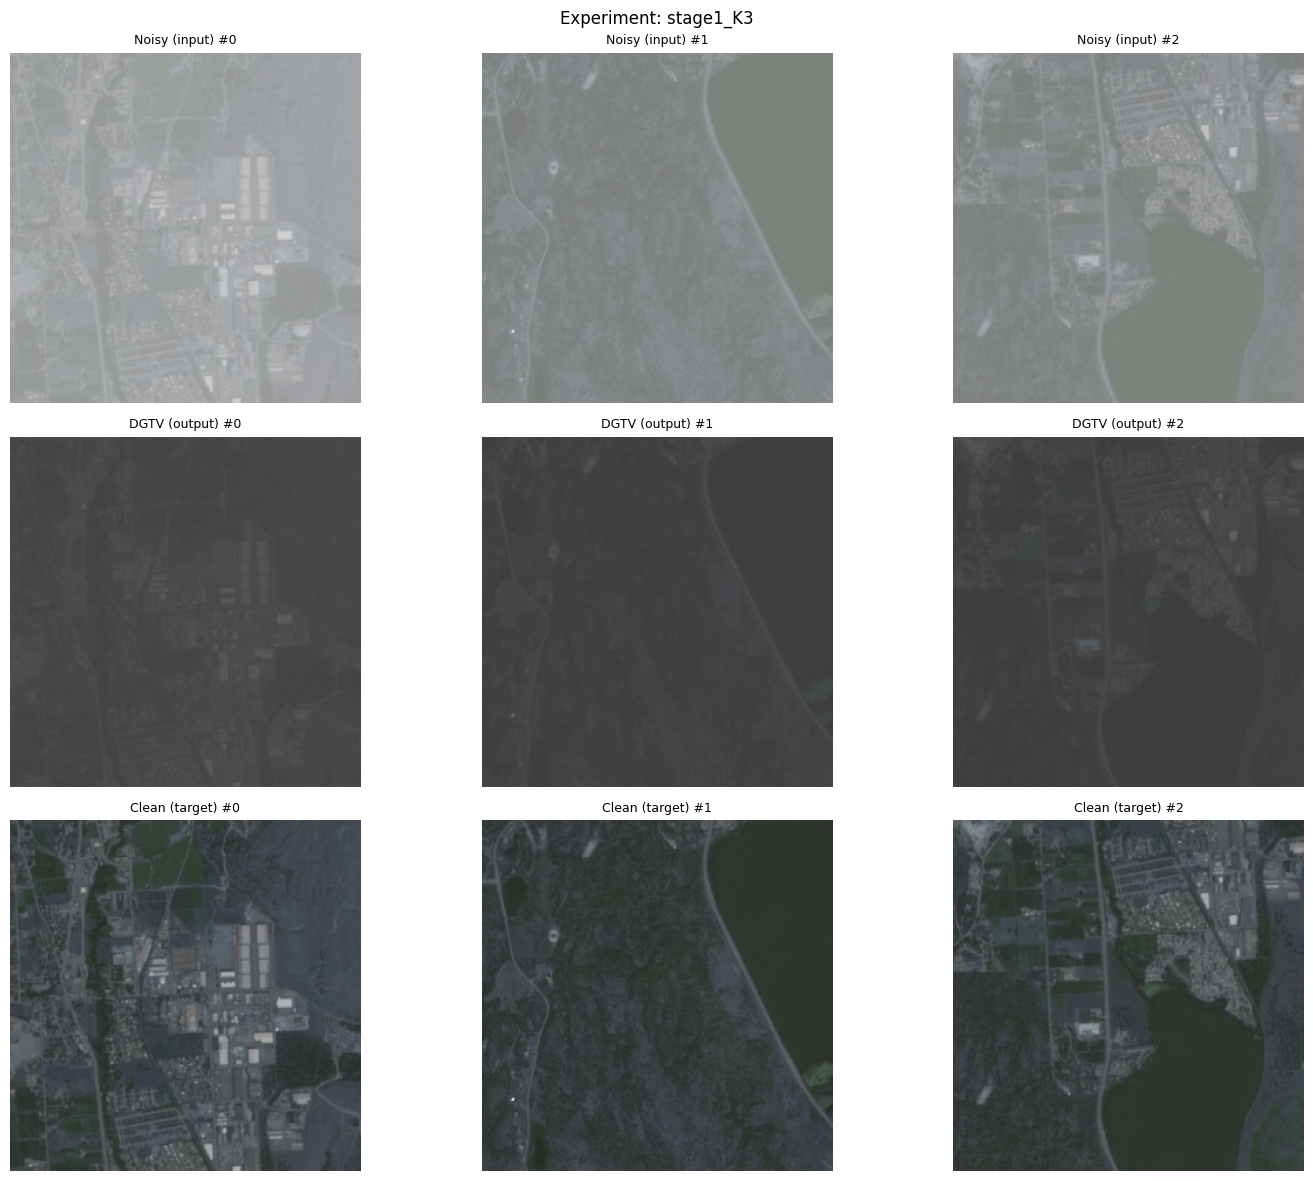


SUMMARY
  experiment: stage1_K3
  K: 3
  T: 1
  optimizer: Adam
  lr: 0.01
  params: 48932
  best_epoch: 7
  best_psnr: 27.5188
  best_ssim: 0.8282

Results saved to /home/park.juw/results/stage1_K3


In [1]:
# ============================================================
# DGTV Wildfire Smoke Removal — Model + Training (Colab)
# DGTV 산불 연기 제거 — 모델 및 학습 (Colab)
#
# Experiment order / 실험 순서:
#   Stage 1: K = 3, 6, 9  (T=1, SGD fixed / SGD 고정)
#   Stage 2: SGD vs Adam   (best K, T=1)
#   Stage 3: T = 1 vs 2    (best K, best optimizer)
#
# Usage / 사용법:
#   Set EXPERIMENT and K below, then Run All
#   아래 EXPERIMENT 및 K 설정 후 모두 실행

#
#Pipeline:
#1. Initialize Model Architecture (DGTV)
#2. Load Dataset & Prepare Batches
#3. Construct Dynamic Graph (Graph building)
#4. Approximate Graph Filtering (Lanczos Method)
#5. Optimization & Backpropagation
#6. Evaluate & Save Best Performance
# ============================================================

# ── 0. Setup / 설정 ─────────────────────────────────────────
import os, time, json
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from skimage.metrics import peak_signal_noise_ratio as calc_psnr
from skimage.metrics import structural_similarity as calc_ssim
import matplotlib.pyplot as plt

# GPU setup / GPU 설정
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")

# ── 1. Experiment Configuration / 실험 구성 ──────────────────────────────
# !! Change these for each experiment !! / !! 실험마다 아래 값을 수정하세요 !!

EXPERIMENT = 'stage1_K3'   # stage1_K3 / stage1_K6 / stage1_K9
                           # stage3_T1 / stage3_T2

CONFIG = {
    # Stage 1: K comparison (T=1, Adam) / K 값 비교
    'stage1_K3':  dict(K=3, T=1, optim='Adam', lr=1e-2),
    'stage1_K6':  dict(K=6, T=1, optim='Adam', lr=1e-2),
    'stage1_K9':  dict(K=9, T=1, optim='Adam', lr=1e-2),
    # Stage 3: Layer comparison (best K, Adam) / 레이어 수 T 비교
    'stage3_T1':  dict(K=3, T=1, optim='Adam', lr=1e-2),
    'stage3_T2':  dict(K=3, T=2, optim='Adam', lr=1e-2),
}

cfg = CONFIG[EXPERIMENT]
K, T, OPTIM, LR = cfg['K'], cfg['T'], cfg['optim'], cfg['lr']

# Fixed hyperparameters (paper settings) / 고정 하이퍼파라미터 (논문 설정)
B_BLOCKS  = 6       # blocks per layer / 레이어당 블록 수
M_LANCZOS = 20      # Lanczos approximation order / 란초스 근사 차수
EPSILON   = 0.3     # Gaussian kernel parameter / 가우시안 커널 파라미터
RHO       = 0.01    # l1-Laplacian stability parameter / l1-라플라시안 안정화 파라미터
BATCH     = 4       # batch size / 배치 크기
MAX_EPOCH = 50      # max epochs / 최대 에포크
PATIENCE  = 10      # early stopping patience / 조기 종료 대기 횟수

# Path adjustment / 경로 수정
DATA_DIR  = '/home/park.juw'
SAVE_DIR  = f'/home/park.juw/results/{EXPERIMENT}'
os.makedirs(SAVE_DIR, exist_ok=True)

print(f"\nExperiment : {EXPERIMENT}")
print(f"K={K}, T={T}, Optimizer={OPTIM}, LR={LR}")

# ════════════════════════════════════════════════════════════
# 2. Dataset / 데이터셋
# ════════════════════════════════════════════════════════════
class WildfireDataset(Dataset):
    """Custom Dataset for loading .npy files / .npy 파일을 로드하기 위한 커스텀 데이터셋"""
    def __init__(self, noisy_path, clean_path):
        self.noisy = torch.from_numpy(np.load(noisy_path)).float()
        self.clean = torch.from_numpy(np.load(clean_path)).float()
    def __len__(self): return len(self.noisy)
    def __getitem__(self, i): return self.noisy[i], self.clean[i]

train_ds = WildfireDataset(
    os.path.join(DATA_DIR, 'train_noisy_aug.npy'),
    os.path.join(DATA_DIR, 'train_clean_aug.npy')
)
test_ds = WildfireDataset(
    os.path.join(DATA_DIR, 'test_noisy.npy'),
    os.path.join(DATA_DIR, 'test_clean.npy')
)
train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,  num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)
print(f"\nTrain: {len(train_ds):,} | Test: {len(test_ds):,}")

# ════════════════════════════════════════════════════════════
# 3. Model Components / 모델 구성 요소
# ════════════════════════════════════════════════════════════

# ── CNN_F: Feature extraction / 특징 추출 ─────────────────────────────
class CNN_F(nn.Module):
    """
    4-layer CNN: extracts K features per pixel.
    4개 레이어 CNN: 픽셀당 K개의 특징을 추출합니다.
    3 -> 32 -> 32 -> 32 -> K, ReLU after first 3 layers.
    """
    def __init__(self, K=3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3,  32, 3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, 3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, 3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(32, K,  3, padding=1),
        )
    def forward(self, x): return self.net(x)  # (B, K, H, W)


# ── CNN_mu: Regularization parameter estimation / 정규화 파라미터 추정 ──────────
class CNN_mu(nn.Module):
    """
    4 conv layers + max pooling + FC.
    Outputs positive scalar mu per patch via Softplus.
    패치별 양수 값인 mu를 Softplus를 통해 출력합니다.
    """
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3,  32, 3, padding=1), nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Conv2d(32, 32, 3, padding=1), nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Conv2d(32, 32, 3, padding=1), nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Conv2d(32, 32, 3, padding=1), nn.ReLU(inplace=True),
        )
        self.fc = nn.Linear(32, 1)

    def forward(self, x):
        h  = self.conv(x).mean(dim=[2,3])   # global avg pool -> (B, 32)
        return F.softplus(self.fc(h))        # (B, 1) positive / 양수 출력


# ── Graph operations / 그래프 연산 ──────────────────────────────────────
OFFSETS = [(-1,-1),(-1,0),(-1,1),(0,-1),(0,1),(1,-1),(1,0),(1,1)]

def get_neighbor(x, dh, dw):
    """Shift x by (dh, dw) with replicate boundary padding / x를 (dh, dw)만큼 이동시키며 경계면을 복사하여 패딩합니다."""
    ph, pw = abs(dh), abs(dw)
    xp = F.pad(x, (pw, pw, ph, ph), mode='replicate')
    H, W = x.shape[2], x.shape[3]
    return xp[:, :, ph+dh:ph+dh+H, pw+dw:pw+dw+W]

def build_graph_weights(features, epsilon):
    """
    8-neighborhood edge weights / 8-이웃 에지 가중치: w_ij = exp(-||f_i-f_j||^2 / eps^2)
    Returns list of 8 tensors, each (B, 1, H, W)
    """
    ws = []
    for dh, dw in OFFSETS:
        d2 = ((features - get_neighbor(features, dh, dw))**2).sum(1, keepdim=True)
        ws.append(torch.exp(-d2 / epsilon**2))
    return ws

def build_gamma(ws, x, rho):
    """
    l1-Laplacian weights / l1-라플라시안 가중치: Gamma_ij = w_ij / max(|xi-xj|_avg, rho)
    """
    gs = []
    for i, (dh, dw) in enumerate(OFFSETS):
        diff = torch.abs(x - get_neighbor(x, dh, dw)).mean(1, keepdim=True)
        gs.append(ws[i] / diff.clamp(min=rho))
    return gs

def laplacian_mv(gs, v):
    """
    L_Gamma * v = D*v - sum_j Gamma_ij * v_j
    Sparse matrix-vector product via neighbor operations / 이웃 연산을 통한 희소 행렬-벡터 곱.
    """
    degree = sum(gs)          # (B, 1, H, W)
    out = degree * v
    for i, (dh, dw) in enumerate(OFFSETS):
        out = out - gs[i] * get_neighbor(v, dh, dw)
    return out


# ── Lanczos filter / 란초스 필터 ────────────────────────────────────────
def lanczos_filter(gs, y, mu, M):
    """
    Approximate x* = (I + mu*L_Gamma)^{-1} y via Lanczos method.
    란초스 방법을 통한 x* 근사 연산.
    Ref: Susnjara et al. (2015), arXiv:1509.04537
    """
    B = y.shape[0]
    mu4 = mu.view(B, 1, 1, 1)

    # Normalize starting vector / 시작 벡터 정규화
    norm_y  = y.view(B, -1).norm(dim=1).view(B, 1, 1, 1).clamp(min=1e-8)
    v_curr  = y / norm_y
    v_prev  = torch.zeros_like(y)
    beta_p  = torch.zeros(B, 1, 1, 1, device=y.device)

    alphas, betas, V = [], [], [v_curr]

    for _ in range(M):
        Lv    = laplacian_mv(gs, v_curr)
        alpha = (Lv * v_curr).view(B, -1).sum(1).view(B, 1, 1, 1)
        alphas.append(alpha)

        w    = Lv - alpha * v_curr - beta_p * v_prev
        beta = w.view(B, -1).norm(dim=1).view(B, 1, 1, 1).clamp(min=1e-8)
        betas.append(beta)

        v_prev, v_curr, beta_p = v_curr, w / beta, beta
        V.append(v_curr)

    V = V[:M]   # keep M vectors / M개의 벡터 유지

    # Per-batch element processing / 배치 요소별 처리
    results = []
    for b in range(B):
        a_b = torch.stack([alphas[m][b,0,0,0] for m in range(M)])
        H   = torch.diag(a_b)
        if M > 1:
            bt  = torch.stack([betas[m][b,0,0,0] for m in range(M-1)])
            H   = H + torch.diag(bt, 1) + torch.diag(bt, -1)

        H = H + torch.eye(M, device=H.device, dtype=H.dtype) * 1e-6  # regularization / 정규화
        evals, evecs = torch.linalg.eigh(H.double())  # Stability: float64 / 수치 안정성 확보
        evals  = evals.float()
        evecs  = evecs.float()
        f_eig = 1.0 / (1.0 + mu[b,0] * evals)       # Keep gradient / 그래디언트 유지

        e1       = torch.zeros(M, device=y.device, dtype=y.dtype)
        e1[0]    = 1.0
        f_H_e1   = evecs @ (f_eig * (evecs.T @ e1))  # (M,)

        V_b      = torch.stack([V[m][b] for m in range(M)])  # (M, C, H, W)
        result_b = norm_y[b,0,0,0] * (f_H_e1.view(-1,1,1,1) * V_b).sum(0)
        results.append(result_b)

    return torch.stack(results)


# ── GTV Block / GTV 블록 ─────────────────────────────────────────────
class GTVBlock(nn.Module):
    """One optimization iteration: update Gamma from x, then filter / 1회 최적화 반복: x로부터 Gamma 업데이트 후 필터링."""
    def __init__(self, M=20, rho=0.01):
        super().__init__()
        self.M, self.rho = M, rho

    def forward(self, x, y, ws, mu):
        gs    = build_gamma(ws, x, self.rho)
        x_new = lanczos_filter(gs, y, mu, self.M)
        return x_new


# ── GTV Layer / GTV 레이어 ─────────────────────────────────────────────
class GTVLayer(nn.Module):
    """B blocks sharing one CNN_F and CNN_mu / CNN_F와 CNN_mu를 공유하는 B개의 블록."""
    def __init__(self, B_blocks=6, K=3, M=20, epsilon=0.3, rho=0.01):
        super().__init__()
        self.epsilon = epsilon
        self.cnn_f   = CNN_F(K)
        self.cnn_mu  = CNN_mu()
        self.blocks  = nn.ModuleList([GTVBlock(M, rho) for _ in range(B_blocks)])

    def forward(self, x, y):
        feat = self.cnn_f(y)
        mu   = self.cnn_mu(y)
        ws   = build_graph_weights(feat, self.epsilon)
        for blk in self.blocks:
            x = blk(x, y, ws, mu)
        return x


# ── DGTV 모델 ─────────────────────────────────────────────────
class DGTV(nn.Module):
    """
    Deep GTV: T layers, each with B blocks.
    Deep GTV: T개의 레이어, 각 레이어는 B개의 블록을 포함.
    Input:  noisy patch y  (B, 3, H, W)
    Output: denoised patch (B, 3, H, W)
    """
    def __init__(self, T=1, B_blocks=6, K=3, M=20, epsilon=0.3, rho=0.01):
        super().__init__()
        self.layers = nn.ModuleList([
            GTVLayer(B_blocks, K, M, epsilon, rho) for _ in range(T)
        ])

    def forward(self, y):
        x = y.clone()
        for layer in self.layers:
            x = layer(x, y)
        return x


# ════════════════════════════════════════════════════════════
# 4. Training Utilities / 학습 유틸리티
# ════════════════════════════════════════════════════════════
def count_params(model):
    """Count trainable parameters / 학습 가능한 파라미터 수 계산"""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def evaluate(model, loader):
    """Evaluation on validation/test set / 검증/테스트 셋 평가"""
    model.eval()
    psnr_list, ssim_list, loss_list = [], [], []
    criterion = nn.MSELoss()
    with torch.no_grad():
        for noisy, clean in loader:
            noisy, clean = noisy.to(DEVICE), clean.to(DEVICE)
            pred  = model(noisy)
            loss  = criterion(pred, clean)
            loss_list.append(loss.item())
            for i in range(pred.shape[0]):
                p = pred[i].cpu().numpy().transpose(1,2,0).clip(0,1)
                c = clean[i].cpu().numpy().transpose(1,2,0)
                psnr_list.append(calc_psnr(c, p, data_range=1.0))
                ssim_list.append(calc_ssim(c, p, data_range=1.0, channel_axis=-1))
    return np.mean(loss_list), np.mean(psnr_list), np.mean(ssim_list)

def train_one_epoch(model, loader, optimizer, criterion):
    """Training for one epoch / 1 에포크 학습"""
    model.train()
    losses = []
    for noisy, clean in loader:
        noisy, clean = noisy.to(DEVICE), clean.to(DEVICE)
        optimizer.zero_grad()
        pred = model(noisy)
        loss = criterion(pred, clean)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        losses.append(loss.item())
    return np.mean(losses)

def visualize_results(model, loader, save_path, n=3):
    """Visualize and save sample results / 샘플 결과 시각화 및 저장"""
    model.eval()
    noisy, clean = next(iter(loader))
    noisy, clean = noisy[:n].to(DEVICE), clean[:n].to(DEVICE)
    with torch.no_grad():
        pred = model(noisy)
    fig, axes = plt.subplots(3, n, figsize=(5*n, 12))
    titles = ['Noisy (input)', 'DGTV (output)', 'Clean (target)']
    for col in range(n):
        for row, img_t in enumerate([noisy, pred, clean]):
            img = img_t[col].cpu().numpy().transpose(1,2,0).clip(0,1)
            axes[row, col].imshow(img)
            axes[row, col].set_title(f'{titles[row]} #{col}', fontsize=9)
            axes[row, col].axis('off')
    plt.suptitle(f'Experiment: {EXPERIMENT}', fontsize=12)
    plt.tight_layout()
    plt.savefig(save_path, dpi=80)
    plt.show()


# ════════════════════════════════════════════════════════════
# 5. Main Training Loop / 메인 학습 루프
# ════════════════════════════════════════════════════════════
model = DGTV(T=T, B_blocks=B_BLOCKS, K=K, M=M_LANCZOS,
             epsilon=EPSILON, rho=RHO).to(DEVICE)
print(f"\nModel parameters: {count_params(model):,}")

criterion = nn.MSELoss()

# Set different learning rates for sub-networks / 서브 네트워크별 다른 학습률 설정
param_groups = [
    {'params': [p for n, p in model.named_parameters() if 'cnn_f' in n],  'lr': LR},
    {'params': [p for n, p in model.named_parameters() if 'cnn_mu' in n], 'lr': LR * 0.1},
]
optimizer = torch.optim.Adam(param_groups)

# Check gradient flow / 그래디언트 흐름 확인
def check_gradients(model):
    total, zero = 0, 0
    for name, p in model.named_parameters():
        if p.grad is not None:
            total += 1
            if p.grad.abs().max().item() < 1e-8:
                zero += 1
    print(f"  Gradient check: {total} params, {zero} near-zero")

# Learning rate scheduler / 학습률 스케줄러
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)

# Training loop with early stopping / 조기 종료를 포함한 학습 루프
best_psnr   = 0.0
best_epoch  = 0
no_improve  = 0
history     = {'train_loss': [], 'val_loss': [], 'val_psnr': [], 'val_ssim': []}

print(f"\nTraining started — max {MAX_EPOCH} epochs, early stopping patience={PATIENCE}")
print("=" * 60)

for epoch in range(1, MAX_EPOCH + 1):
    t0 = time.time()

    train_loss                   = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_psnr, val_ssim = evaluate(model, test_loader)
    scheduler.step(val_loss)

    # Check gradients for first 3 epochs / 초기 3 에포크 동안 그래디언트 확인
    if epoch <= 3:
        check_gradients(model)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_psnr'].append(val_psnr)
    history['val_ssim'].append(val_ssim)

    elapsed = time.time() - t0
    print(f"Epoch {epoch:3d}/{MAX_EPOCH} | "
          f"Train loss: {train_loss:.5f} | "
          f"Val PSNR: {val_psnr:.2f} dB | "
          f"SSIM: {val_ssim:.4f} | "
          f"Time: {elapsed:.1f}s")

    # Save best model / 최적 모델 저장
    if val_psnr > best_psnr:
        best_psnr  = val_psnr
        best_epoch = epoch
        no_improve = 0
        torch.save(model.state_dict(),
                   os.path.join(SAVE_DIR, 'best_model.pth'))
        print(f"  -> Best model saved (PSNR: {best_psnr:.2f} dB)")
    else:
        no_improve += 1
        if no_improve >= PATIENCE:
            print(f"\nEarly stopping at epoch {epoch} "
                  f"(no improvement for {PATIENCE} epochs)")
            break

print(f"\nBest PSNR: {best_psnr:.2f} dB at epoch {best_epoch}")

# ════════════════════════════════════════════════════════════
# 6. Save Results & Visualize / 결과 저장 및 시각화
# ════════════════════════════════════════════════════════════

# Save training history / 학습 기록 저장
with open(os.path.join(SAVE_DIR, 'history.json'), 'w') as f:
    json.dump({k: [float(v) for v in vals] for k, vals in history.items()}, f)

# Plot training curves / 학습 곡선 그리기
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(history['train_loss'], label='Train')
axes[0].plot(history['val_loss'],   label='Val')
axes[0].set_title('Loss'); axes[0].legend(); axes[0].set_xlabel('Epoch')

axes[1].plot(history['val_psnr'])
axes[1].axhline(28, color='r', linestyle='--', label='Target 28dB')
axes[1].set_title('Val PSNR (dB)'); axes[1].legend(); axes[1].set_xlabel('Epoch')

axes[2].plot(history['val_ssim'])
axes[2].axhline(0.75, color='r', linestyle='--', label='Target 0.75')
axes[2].set_title('Val SSIM'); axes[2].legend(); axes[2].set_xlabel('Epoch')

plt.suptitle(f'{EXPERIMENT} | Best PSNR: {best_psnr:.2f} dB', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'training_curves.png'), dpi=100)
plt.show()

# Load best model and visualize / 최적 모델 로드 및 시각화
model.load_state_dict(torch.load(os.path.join(SAVE_DIR, 'best_model.pth')))
visualize_results(model, test_loader,
                  os.path.join(SAVE_DIR, 'visual_results.png'))

# Save summary / 요약 정보 저장
summary = {
    'experiment':  EXPERIMENT,
    'K': int(K), 'T': int(T), 'optimizer': OPTIM, 'lr': float(LR),
    'params':      int(count_params(model)),
    'best_epoch':  int(best_epoch),
    'best_psnr':   round(float(best_psnr), 4),
    'best_ssim':   round(float(history['val_ssim'][best_epoch-1]), 4),
}
with open(os.path.join(SAVE_DIR, 'summary.json'), 'w') as f:
    json.dump(summary, f, indent=2)

print("\n" + "=" * 60)
print("SUMMARY")
print("=" * 60)
for k, v in summary.items():
    print(f"  {k}: {v}")
print(f"\nResults saved to {SAVE_DIR}")

### Smoky image check

Device: cuda
Model loaded from /home/park.juw/results/stage1_K3/best_model.pth

Found 5 images
Processing: T10UGA_20210805T185919_TCI_10m.jp2
Processing: T10UGA_20230517T185919_TCI_10m.jp2
Processing: T10UGA_20230820T185921_TCI_10m.jp2
Processing: T10UGA_20230825T185919_TCI_10m.jp2
Processing: T10UGA_20230830T185921_TCI_10m.jp2


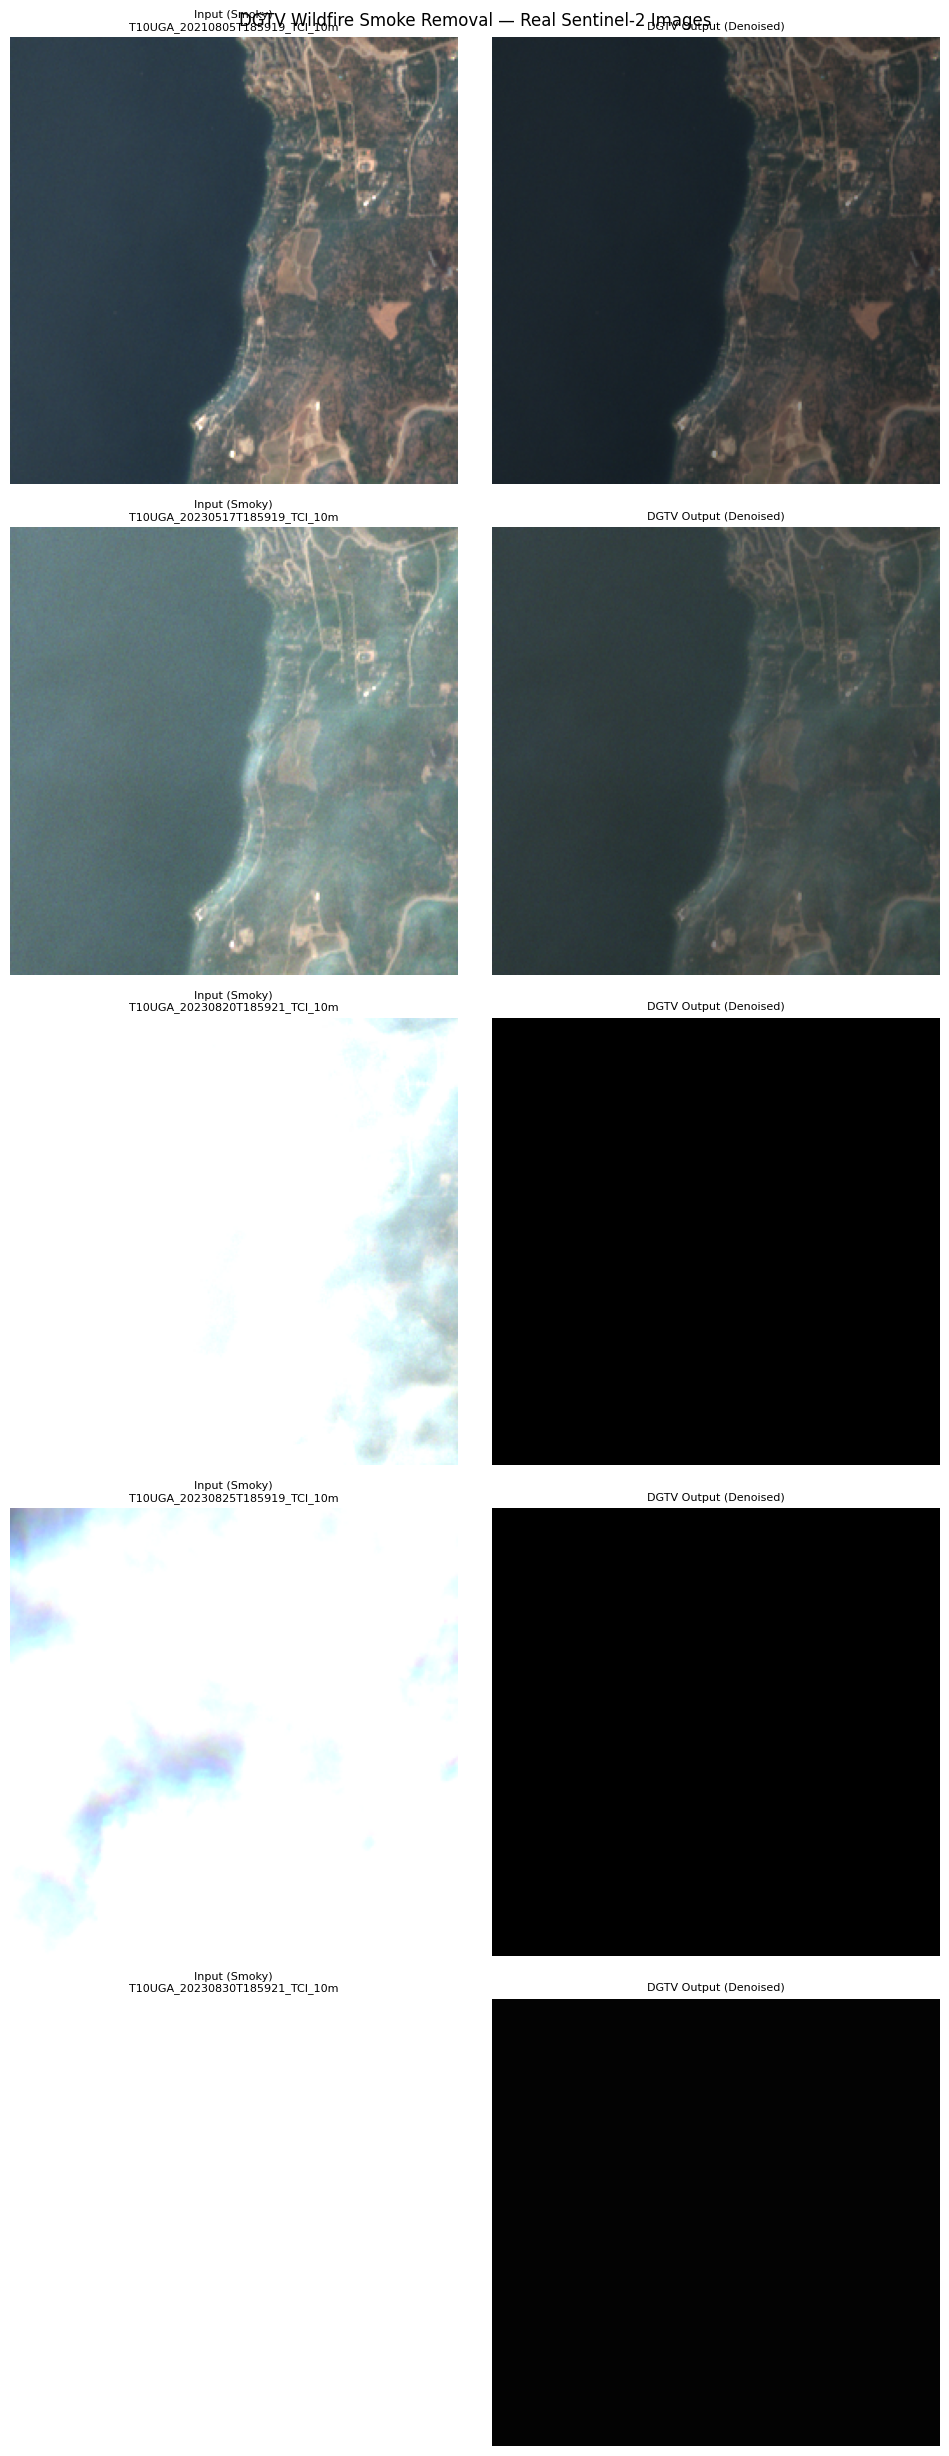


Results saved to /home/park.juw/results/inference/real_smoke_results.png


In [1]:
# ============================================================
# DGTV Inference on Real Smoky Satellite Images
# DGTV 실제 연기 낀 위성 이미지 추론 (통합 코드)
# ============================================================

import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import rasterio
import glob

# Device setup / 장치 설정 (GPU 사용 가능 시 CUDA, 아니면 CPU)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")

# ── Paths / 경로 설정 ─────────────────────────────────────────────────
SMOKY_DIR  = '/home/park.juw/Smoky'                            # Input directory / 입력 이미지 경로
MODEL_PATH = '/home/park.juw/results/stage1_K3/best_model.pth' # Model path / 학습된 모델 가중치 경로
SAVE_DIR   = '/home/park.juw/results/inference'                # Output directory / 결과 저장 경로
os.makedirs(SAVE_DIR, exist_ok=True)

# ── Model Parameters / 모델 제어 파라미터 ──────────────────────────────
K          = 3      # Feature dimension / 픽셀별 특징 추출 차원
T          = 1      # Number of DGTV layers / 전체 DGTV 레이어 개수
B_BLOCKS   = 6      # Iterations per layer / 레이어당 내부 반복 최적화 횟수
M_LANCZOS  = 20     # Lanczos order / 란초스 알고리즘 근사 정밀도 차수
EPSILON    = 0.3    # Gaussian kernel scale / 픽셀 유사도 판단 기준값
RHO        = 0.01   # Stability parameter / 수치적 안정성을 위한 최소값 (분모 0 방지)
PATCH_SIZE = 256    # Inference image size / 추론 시 사용할 이미지 크기 (256x256)

# ════════════════════════════════════════════════════════════
# 1. Model Definition / 모델 정의
# ════════════════════════════════════════════════════════════

class CNN_F(nn.Module):
    """Extracts K features per pixel for graph construction / 그래프 구성을 위해 픽셀당 K개의 특징을 추출합니다."""
    def __init__(self, K=3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3,  32, 3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, 3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, 3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(32, K,  3, padding=1),
        )
    def forward(self, x): return self.net(x)

class CNN_mu(nn.Module):
    """Estimates regularization parameter mu from input / 입력 영상에서 정규화 파라미터 mu를 추정합니다."""
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3,  32, 3, padding=1), nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Conv2d(32, 32, 3, padding=1), nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Conv2d(32, 32, 3, padding=1), nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Conv2d(32, 32, 3, padding=1), nn.ReLU(inplace=True),
        )
        self.fc = nn.Linear(32, 1)
    def forward(self, x):
        h = self.conv(x).mean(dim=[2,3])
        return F.softplus(self.fc(h))

OFFSETS = [(-1,-1),(-1,0),(-1,1),(0,-1),(0,1),(1,-1),(1,0),(1,1)]

def get_neighbor(x, dh, dw):
    """Accesses adjacent pixels using spatial shift / 공간 이동을 통해 인접 픽셀 데이터에 접근합니다."""
    ph, pw = abs(dh), abs(dw)
    xp = F.pad(x, (pw, pw, ph, ph), mode='replicate')
    H, W = x.shape[2], x.shape[3]
    return xp[:, :, ph+dh:ph+dh+H, pw+dw:pw+dw+W]

def build_graph_weights(features, epsilon):
    """Computes edge weights using feature similarity / 특징 유사도를 기반으로 그래프 에지 가중치를 계산합니다."""
    ws = []
    for dh, dw in OFFSETS:
        d2 = ((features - get_neighbor(features, dh, dw))**2).sum(1, keepdim=True)
        ws.append(torch.exp(-d2 / epsilon**2))
    return ws

def build_gamma(ws, x, rho):
    """Constructs l1-Laplacian weights (Gamma) / l1-라플라시안 가중치(Gamma)를 구성합니다."""
    gs = []
    for i, (dh, dw) in enumerate(OFFSETS):
        diff = torch.abs(x - get_neighbor(x, dh, dw)).mean(1, keepdim=True)
        gs.append(ws[i] / diff.clamp(min=rho))
    return gs

def laplacian_mv(gs, v):
    """Computes Sparse Laplacian-Vector product / 희소 라플라시안 행렬과 벡터의 곱을 계산합니다."""
    degree = sum(gs)
    out = degree * v
    for i, (dh, dw) in enumerate(OFFSETS):
        out = out - gs[i] * get_neighbor(v, dh, dw)
    return out

def lanczos_filter(gs, y, mu, M):
    """Approximate solution for GTV optimization via Lanczos / 란초스법을 이용해 GTV 최적화 해를 근사합니다."""
    B = y.shape[0]
    norm_y = y.view(B, -1).norm(dim=1).view(B, 1, 1, 1).clamp(min=1e-8)
    v_curr = y / norm_y
    v_prev = torch.zeros_like(y)
    beta_p = torch.zeros(B, 1, 1, 1, device=y.device)
    alphas, betas, V = [], [], [v_curr]

    for _ in range(M):
        Lv    = laplacian_mv(gs, v_curr)
        alpha = (Lv * v_curr).view(B, -1).sum(1).view(B, 1, 1, 1)
        alphas.append(alpha)
        w    = Lv - alpha * v_curr - beta_p * v_prev
        beta = w.view(B, -1).norm(dim=1).view(B, 1, 1, 1).clamp(min=1e-8)
        betas.append(beta)
        v_prev, v_curr, beta_p = v_curr, w / beta, beta
        V.append(v_curr)

    V = V[:M]
    results = []
    for b in range(B):
        a_b = torch.stack([alphas[m][b,0,0,0] for m in range(M)])
        H   = torch.diag(a_b)
        if M > 1:
            bt = torch.stack([betas[m][b,0,0,0] for m in range(M-1)])
            H  = H + torch.diag(bt, 1) + torch.diag(bt, -1)
        H = H + torch.eye(M, device=H.device, dtype=H.dtype) * 1e-6
        evals, evecs = torch.linalg.eigh(H.double())
        evals  = evals.float()
        evecs  = evecs.float()
        f_eig  = 1.0 / (1.0 + mu[b,0] * evals)
        e1     = torch.zeros(M, device=y.device, dtype=y.dtype)
        e1[0]  = 1.0
        f_H_e1 = evecs @ (f_eig * (evecs.T @ e1))
        V_b    = torch.stack([V[m][b] for m in range(M)])
        results.append(norm_y[b,0,0,0] * (f_H_e1.view(-1,1,1,1) * V_b).sum(0))
    return torch.stack(results)

class GTVBlock(nn.Module):
    """A single GTV iteration block / 단일 GTV 반복 연산을 수행하는 블록입니다."""
    def __init__(self, M=20, rho=0.01):
        super().__init__()
        self.M, self.rho = M, rho
    def forward(self, x, y, ws, mu):
        gs = build_gamma(ws, x, self.rho)
        return lanczos_filter(gs, y, mu, self.M)

class GTVLayer(nn.Module):
    """Layer containing feature extraction and GTV blocks / 특징 추출과 GTV 블록들을 포함하는 레이어입니다."""
    def __init__(self, B_blocks=6, K=3, M=20, epsilon=0.3, rho=0.01):
        super().__init__()
        self.epsilon = epsilon
        self.cnn_f   = CNN_F(K)
        self.cnn_mu  = CNN_mu()
        self.blocks  = nn.ModuleList([GTVBlock(M, rho) for _ in range(B_blocks)])
    def forward(self, x, y):
        feat = self.cnn_f(y)
        mu   = self.cnn_mu(y)
        ws   = build_graph_weights(feat, self.epsilon)
        for blk in self.blocks:
            x = blk(x, y, ws, mu)
        return x

class DGTV(nn.Module):
    """Deep Graph Total Variation (DGTV) Model / 심층 그래프 전체 변분 모델입니다."""
    def __init__(self, T=1, B_blocks=6, K=3, M=20, epsilon=0.3, rho=0.01):
        super().__init__()
        self.layers = nn.ModuleList([
            GTVLayer(B_blocks, K, M, epsilon, rho) for _ in range(T)
        ])
    def forward(self, y):
        x = y.clone()
        for layer in self.layers:
            x = layer(x, y)
        return x

# ════════════════════════════════════════════════════════════
# 2. Load Model / 모델 로드
# ════════════════════════════════════════════════════════════
model = DGTV(T=T, B_blocks=B_BLOCKS, K=K, M=M_LANCZOS,
             epsilon=EPSILON, rho=RHO).to(DEVICE)
model.load_state_dict(torch.load(MODEL_PATH, weights_only=True))
model.eval()
print(f"Model loaded from {MODEL_PATH}")

# ════════════════════════════════════════════════════════════
# 3. Image Loading & Preprocessing / 이미지 로드 및 전처리
# ════════════════════════════════════════════════════════════
def load_tci_jp2(path, patch_size=256):
    """Loads S2 JP2 image, crops center patch, and normalizes / 위성 이미지를 불러와 중앙을 자르고 정규화합니다."""
    with rasterio.open(path) as src:
        H, W = src.height, src.width
        h_start = (H - patch_size) // 2
        w_start = (W - patch_size) // 2
        window = rasterio.windows.Window(w_start, h_start, patch_size, patch_size)
        img = src.read(window=window)  # (3, H, W)

    img = img.astype(np.float32)
    max_val = img.max()
    # Normalize based on bit-depth / 비트 심도에 따른 정규화 (12비트 위성 영상 대응)
    if max_val > 255:
        img = img / 4095.0
    else:
        img = img / 255.0
    img = np.clip(img, 0, 1)
    return img

# ════════════════════════════════════════════════════════════
# 4. Inference / 추론 실행
# ════════════════════════════════════════════════════════════
jp2_files = sorted(glob.glob(os.path.join(SMOKY_DIR, '*.jp2')))
print(f"\nFound {len(jp2_files)} images")

results = []
for fpath in jp2_files:
    fname = os.path.basename(fpath)
    print(f"Processing: {fname}")

    img    = load_tci_jp2(fpath, PATCH_SIZE)
    tensor = torch.from_numpy(img).unsqueeze(0).float().to(DEVICE)

    with torch.no_grad():
        output = model(tensor)

    # Convert to numpy for visualization / 시각화를 위해 넘파이 변환
    inp = tensor[0].cpu().numpy().transpose(1,2,0).clip(0,1)
    out = output[0].cpu().numpy().transpose(1,2,0).clip(0,1)
    results.append((fname, inp, out))
    torch.cuda.empty_cache()

# ════════════════════════════════════════════════════════════
# 5. Visualization / 시각화 및 저장
# ════════════════════════════════════════════════════════════
n = len(results)
if n > 0:
    fig, axes = plt.subplots(n, 2, figsize=(10, 5*n))
    if n == 1: axes = [axes]

    for i, (fname, inp, out) in enumerate(results):
        axes[i][0].imshow(inp)
        axes[i][0].set_title(f'Input (Smoky)\n{fname[:30]}', fontsize=8)
        axes[i][0].axis('off')

        axes[i][1].imshow(out)
        axes[i][1].set_title('DGTV Output (Denoised)', fontsize=8)
        axes[i][1].axis('off')

    plt.suptitle('DGTV Wildfire Smoke Removal — Real Sentinel-2 Images', fontsize=12)
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, 'real_smoke_results.png'), dpi=100, bbox_inches='tight')
    plt.show()
    print(f"\nResults saved to {SAVE_DIR}/real_smoke_results.png")